Extended Data Figure 15 - Enrichment of a T-cell pre-commitment TF module in CSC-associated gene regulatory networks across patients


Input: GRNs-Lists-for-Steven-5-with-no-RSS-scores-all-for-analyses.xlsx
Stem GRNs: 6 | Diff GRNs: 7
TF universe: 160
Module TFs detected: ['BCL11A', 'ERG', 'RUNX1', 'SPI1', 'TCF12']
Module TFs absent: ['LMO2', 'LYL1', 'TCF3']


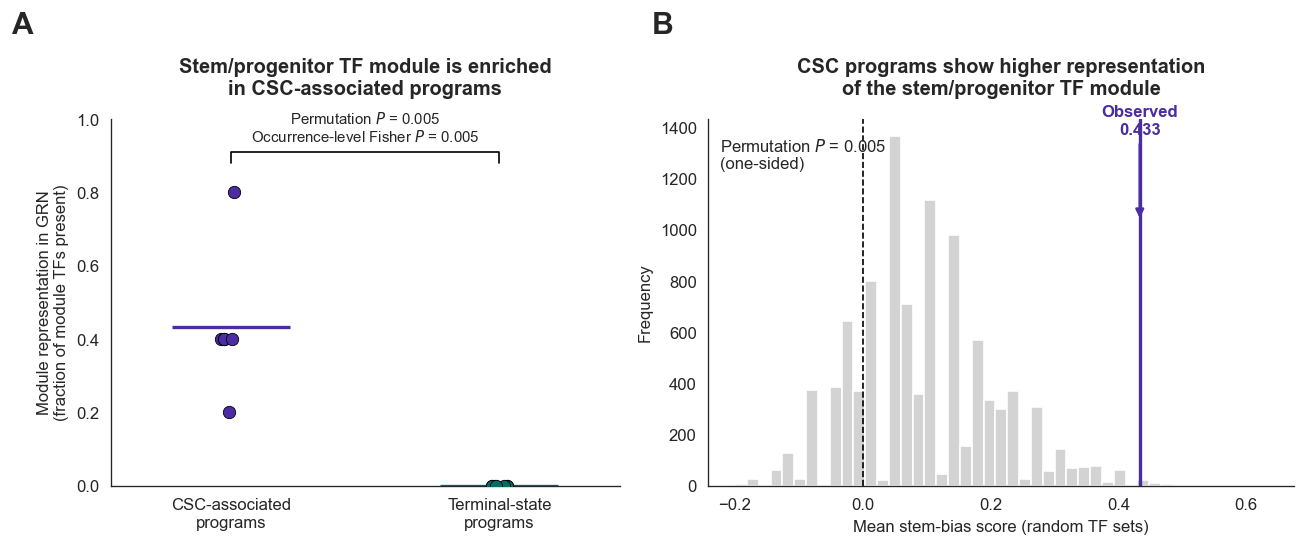

In [2]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import fisher_exact
from pathlib import Path

# ============================================================
# USER SETTINGS — same Excel as IoU analysis
# ============================================================

GRN_EXCEL = Path(
    "PATH_TO_FIGURES/Box_Plots/"
    "GRNs-Lists-for-Steven-5-with-no-RSS-scores-all-for-analyses.xlsx"
)
STEM_SHEET = "Stem"
DIFF_SHEET = "Diff"

# Published T-cell pre-commitment / stem-progenitor TF module
MODULE_TFS_RAW = [
    "PU.1",
    "BCL11A",
    "ERG",
    "LYL1",
    "LMO2",
    "E2A",
    "HEB",
    "RUNX1",
]

N_PERMUTATIONS = 10000
RANDOM_SEED = 123

# ============================================================
# HELPER FUNCTIONS
# ============================================================

def normalize_tf_name(tf):
    tf = str(tf).strip()
    alias_map = {
        "PU.1": "SPI1",
        "PU1": "SPI1",
        "SPI1": "SPI1",
        "HEB": "TCF12",
        "TCF12": "TCF12",
        "E2A": "TCF3",
        "TCF3": "TCF3",
    }
    return alias_map.get(tf, tf)


def extract_master_tf(entry):
    if pd.isna(entry):
        return None
    s = str(entry).strip()
    if s == "":
        return None
    for token in ["_direct_", "_extended_"]:
        if token in s:
            s = s.split(token)[0]
            break
    s = re.sub(r"_(direct|extended).*?$", "", s)
    return normalize_tf_name(s) if s else None


def clean_column_name(col):
    return re.sub(r"\s*\(.*?\)\s*", "", str(col).strip())


def load_grn_sets(excel_file, sheet_name):
    df = pd.read_excel(excel_file, sheet_name=sheet_name)
    cols = [c for c in df.columns if not str(c).startswith("Unnamed")]
    grn_sets = {}
    for col in cols:
        name = clean_column_name(col)
        tfs = set()
        for value in df[col].dropna():
            tf = extract_master_tf(value)
            if tf:
                tfs.add(tf)
        grn_sets[name] = tfs
    return grn_sets


def bh_fdr(pvalues):
    pvalues = np.asarray(pvalues, dtype=float)
    n = len(pvalues)
    order = np.argsort(pvalues)
    ranked = pvalues[order]
    adjusted = np.empty(n)
    running_min = 1.0
    for i in range(n - 1, -1, -1):
        rank = i + 1
        running_min = min(running_min, ranked[i] * n / rank)
        adjusted[i] = running_min
    out = np.empty(n)
    out[order] = np.clip(adjusted, 0, 1)
    return out


def one_sided_fisher_ora(grn_set, signature_set, universe):
    grn_set = set(grn_set)
    signature_set = set(signature_set)
    universe = set(universe)
    overlap = len(grn_set & signature_set)
    a = overlap
    b = len(grn_set) - overlap
    c = len(signature_set) - overlap
    d = len(universe) - a - b - c
    table = [[a, b], [c, d]]
    odds, p = fisher_exact(table, alternative="greater")
    return overlap, odds, p


def calculate_stem_bias(tf_set, stem_sets, diff_sets):
    stem_n = len(stem_sets)
    diff_n = len(diff_sets)
    scores = []
    for tf in tf_set:
        stem_count = sum(tf in s for s in stem_sets.values())
        diff_count = sum(tf in s for s in diff_sets.values())
        stem_freq = stem_count / stem_n
        diff_freq = diff_count / diff_n
        scores.append(stem_freq - diff_freq)
    return np.mean(scores)


# ============================================================
# LOAD DATA
# ============================================================

if not GRN_EXCEL.exists():
    raise FileNotFoundError(f"File not found: {GRN_EXCEL}")

stem_sets = load_grn_sets(GRN_EXCEL, STEM_SHEET)
diff_sets = load_grn_sets(GRN_EXCEL, DIFF_SHEET)
all_sets = {**stem_sets, **diff_sets}
universe = sorted(set().union(*all_sets.values()))

module_tfs = sorted(set(normalize_tf_name(tf) for tf in MODULE_TFS_RAW))
effective_module = sorted(set(module_tfs) & set(universe))
absent_module = sorted(set(module_tfs) - set(universe))

print(f"Input: {GRN_EXCEL.name}")
print(f"Stem GRNs: {len(stem_sets)} | Diff GRNs: {len(diff_sets)}")
print(f"TF universe: {len(universe)}")
print(f"Module TFs detected: {effective_module}")
print(f"Module TFs absent: {absent_module if absent_module else 'None'}")

# ============================================================
# PER-GRN MODULE REPRESENTATION AND ORA
# ============================================================

rows = []
for state, sets in [("CSC-associated", stem_sets), ("Terminal-state", diff_sets)]:
    for grn_name, grn_tfs in sets.items():
        overlap_tfs = sorted(set(grn_tfs) & set(effective_module))
        overlap_count, odds, p = one_sided_fisher_ora(grn_tfs, effective_module, universe)
        module_representation = overlap_count / len(effective_module) if effective_module else np.nan
        rows.append({
            "State": state,
            "GRN": grn_name,
            "GRN_TF_count": len(grn_tfs),
            "Overlap_count": overlap_count,
            "Overlap_TFs": ", ".join(overlap_tfs) if overlap_tfs else "—",
            "Module_representation": module_representation,
            "ORA_odds_ratio": odds,
            "ORA_p_value": p,
        })

per_grn_df = pd.DataFrame(rows)
per_grn_df["ORA_BH_FDR"] = bh_fdr(per_grn_df["ORA_p_value"])

# ============================================================
# TF-LEVEL DISTRIBUTION AND STEM-BIAS
# ============================================================

tf_rows = []
for tf in effective_module:
    stem_count = sum(tf in s for s in stem_sets.values())
    diff_count = sum(tf in s for s in diff_sets.values())
    stem_freq = stem_count / len(stem_sets)
    diff_freq = diff_count / len(diff_sets)
    tf_rows.append({
        "TF": tf,
        "Stem_GRNs_present": stem_count,
        "Diff_GRNs_present": diff_count,
        "Stem_frequency": stem_freq,
        "Diff_frequency": diff_freq,
        "Stem_bias": stem_freq - diff_freq,
    })

tf_distribution_df = pd.DataFrame(tf_rows).sort_values("Stem_bias", ascending=False)
observed_mean_stem_bias = tf_distribution_df["Stem_bias"].mean()

# ============================================================
# RANDOM-SET PERMUTATION TEST
# ============================================================

rng = np.random.default_rng(RANDOM_SEED)
null_scores = []
for _ in range(N_PERMUTATIONS):
    random_tf_set = rng.choice(universe, size=len(effective_module), replace=False)
    null_scores.append(calculate_stem_bias(random_tf_set, stem_sets, diff_sets))
null_scores = np.asarray(null_scores)
permutation_p = (np.sum(null_scores >= observed_mean_stem_bias) + 1) / (N_PERMUTATIONS + 1)

# ============================================================
# OCCURRENCE-LEVEL FISHER TEST
# ============================================================

stem_curated_occurrences = sum(
    tf in grn_tfs for grn_tfs in stem_sets.values() for tf in effective_module
)
diff_curated_occurrences = sum(
    tf in grn_tfs for grn_tfs in diff_sets.values() for tf in effective_module
)
stem_total_tf_occurrences = sum(len(s) for s in stem_sets.values())
diff_total_tf_occurrences = sum(len(s) for s in diff_sets.values())
stem_noncurated_occurrences = stem_total_tf_occurrences - stem_curated_occurrences
diff_noncurated_occurrences = diff_total_tf_occurrences - diff_curated_occurrences

occurrence_table = [
    [stem_curated_occurrences, diff_curated_occurrences],
    [stem_noncurated_occurrences, diff_noncurated_occurrences],
]
occurrence_odds_ratio, occurrence_fisher_p = fisher_exact(occurrence_table, alternative="greater")

# ============================================================
# SUMMARY TABLE
# ============================================================

summary_df = pd.DataFrame({
    "Metric": [
        "Number of CSC/Stem GRNs",
        "Number of terminal-state/Diff GRNs",
        "TF universe size",
        "Input module size after alias normalization",
        "Detected module size",
        "Detected module TFs",
        "Absent module TFs",
        "Observed mean stem-bias score",
        "Permutation P value, one-sided",
        "Occurrence-level Fisher odds ratio",
        "Occurrence-level Fisher P value",
        "Stem curated TF occurrences",
        "Diff curated TF occurrences",
        "Stem total TF occurrences",
        "Diff total TF occurrences",
    ],
    "Value": [
        len(stem_sets),
        len(diff_sets),
        len(universe),
        len(module_tfs),
        len(effective_module),
        ", ".join(effective_module),
        ", ".join(absent_module) if absent_module else "None",
        observed_mean_stem_bias,
        permutation_p,
        occurrence_odds_ratio,
        occurrence_fisher_p,
        stem_curated_occurrences,
        diff_curated_occurrences,
        stem_total_tf_occurrences,
        diff_total_tf_occurrences,
    ],
})

# ============================================================
# DISPLAY TABLES IN NOTEBOOK
# ============================================================

display(summary_df)
display(per_grn_df)
display(tf_distribution_df)

# ============================================================
# FIGURE — inline in notebook
# ============================================================

stem_values = per_grn_df.loc[per_grn_df["State"] == "CSC-associated", "Module_representation"].values
diff_values = per_grn_df.loc[per_grn_df["State"] == "Terminal-state", "Module_representation"].values

fig, axes = plt.subplots(1, 2, figsize=(11, 4.6), dpi=120, gridspec_kw={"width_ratios": [1.0, 1.15]})

stem_color = "#4b2ca3"
diff_color = "#006d67"

# Panel A
ax = axes[0]
rng_plot = np.random.default_rng(10)
x_stem = rng_plot.normal(0, 0.035, size=len(stem_values))
x_diff = rng_plot.normal(1, 0.035, size=len(diff_values))

ax.scatter(x_stem, stem_values, color=stem_color, edgecolor="black", linewidth=0.5, s=55, zorder=3)
ax.scatter(x_diff, diff_values, color=diff_color, edgecolor="black", linewidth=0.5, s=55, zorder=3)
ax.hlines(np.mean(stem_values), -0.22, 0.22, color=stem_color, linewidth=2)
ax.hlines(np.mean(diff_values), 0.78, 1.22, color=diff_color, linewidth=2)

ax.set_xlim(-0.45, 1.45)
ax.set_ylim(0, 1.0)
ax.set_xticks([0, 1])
ax.set_xticklabels(["CSC-associated\nprograms", "Terminal-state\nprograms"], fontsize=10)
ax.set_ylabel("Module representation in GRN\n(fraction of module TFs present)", fontsize=10)
ax.set_title(
    "Stem/progenitor TF module is enriched\nin CSC-associated programs",
    fontsize=12, weight="bold", pad=15,
)

y_bracket = 0.91
ax.plot([0, 0, 1, 1], [y_bracket - 0.03, y_bracket, y_bracket, y_bracket - 0.03], color="black", linewidth=1)
ax.text(
    0.5, y_bracket + 0.02,
    f"Permutation $P$ = {permutation_p:.3f}\nOccurrence-level Fisher $P$ = {occurrence_fisher_p:.3f}",
    ha="center", va="bottom", fontsize=9,
)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Panel B
ax = axes[1]
ax.hist(null_scores, bins=45, color="lightgray", edgecolor="white")
ax.axvline(0, color="black", linestyle="--", linewidth=1)
ax.axvline(observed_mean_stem_bias, color=stem_color, linewidth=2)
ymax = ax.get_ylim()[1]
ax.annotate(
    f"Observed\n{observed_mean_stem_bias:.3f}",
    xy=(observed_mean_stem_bias, ymax * 0.72),
    xytext=(observed_mean_stem_bias, ymax * 0.95),
    ha="center", va="bottom", color=stem_color, fontsize=10, weight="bold",
    arrowprops=dict(arrowstyle="-|>", color=stem_color, lw=1.5),
)
ax.text(
    0.02, 0.95,
    f"Permutation $P$ = {permutation_p:.3f}\n(one-sided)",
    transform=ax.transAxes, ha="left", va="top", fontsize=10,
)
ax.set_xlabel("Mean stem-bias score (random TF sets)", fontsize=10)
ax.set_ylabel("Frequency", fontsize=10)
ax.set_title(
    "CSC programs show higher representation\nof the stem/progenitor TF module",
    fontsize=12, weight="bold", pad=15,
)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.text(0.015, 0.96, "A", fontsize=18, weight="bold")
fig.text(0.50, 0.96, "B", fontsize=18, weight="bold")
fig.tight_layout(rect=[0.02, 0.02, 1, 0.95])
plt.show()
